<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/saeera/canteen_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

####Loading Cleaned dataset

In [2]:
url = "https://raw.githubusercontent.com/sasasaee/ml-project/main/data/canteen_dataset_feature_engineered.csv"

df = pd.read_csv(url)

df.head()

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,...,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,1.50,3.0,4.50,30,7,False,49,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,3.69,2.0,7.38,15,6,True,4,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,1.54,1.5,2.31,29,7,False,48,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.81,1.5,2.71,17,7,False,36,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,4.69,2.0,9.38,3,7,False,22,True,False,True,...,True,False,False,False,True,False,False,False,False,False


#### Understanding the Dataset


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Waste_Weight_kg           2600 non-null   float64
 1   Unit_Price_per_kg         2600 non-null   float64
 2   Cost_Loss                 2600 non-null   float64
 3   Day                       2600 non-null   int64  
 4   Month                     2600 non-null   int64  
 5   Weekend                   2600 non-null   bool   
 6   Day_Number                2600 non-null   int64  
 7   Meal_Dinner               2600 non-null   bool   
 8   Meal_Lunch                2600 non-null   bool   
 9   Food_Category_Rice        2600 non-null   bool   
 10  Food_Category_Soup        2600 non-null   bool   
 11  Food_Category_Vegetables  2600 non-null   bool   
 12  Canteen_Section_B         2600 non-null   bool   
 13  Canteen_Section_C         2600 non-null   bool   
 14  Canteen_

####Separating Features and Target Variable

In [4]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Cost_Loss",
        "Day",
        "Day_Number"
    ]
)

y = df["Waste_Weight_kg"]

print(X.shape)
print(y.shape)

(2600, 20)
(2600,)


In [5]:
X = X.astype(int)
X.head()

,Unit_Price_per_kg,Month,Weekend,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,Food_Category_Vegetables,Canteen_Section_B,Canteen_Section_C,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,3,7,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0
1,2,6,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0
2,1,7,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,1,7,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,2,7,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0


####Splitting into Training and Testing Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(1820, 20)
(780, 20)


##Evaluation Function

In [7]:
def evaluate_model(model, name):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    print(name)
    print("----------------")
    print("MAE:", round(mae,4))
    print("RMSE:", round(rmse,4))
    print("R2:", round(r2,4))
    print()

    return mae, rmse, r2

####Training Linear Regression

In [8]:
lr_model = LinearRegression()
lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

####Evaluation


In [9]:
lr_results = evaluate_model(
    lr_model,
    "Linear Regression"
)

Linear Regression
----------------
MAE: 1.2607
RMSE: 1.457
R2: -0.0027



##Linear Regression Feature Coefficients

In [10]:
lr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

lr_importance = lr_importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)
lr_importance

,Feature,Coefficient
14,Day_of_Week_Thursday,0.281972
3,Meal_Dinner,0.165201
9,Canteen_Section_C,0.150026
8,Canteen_Section_B,0.118774
10,Canteen_Section_D,0.108750
2,Weekend,0.093399
4,Meal_Lunch,0.078404
13,Day_of_Week_Sunday,0.061331
6,Food_Category_Soup,0.049385
7,Food_Category_Vegetables,-0.047522


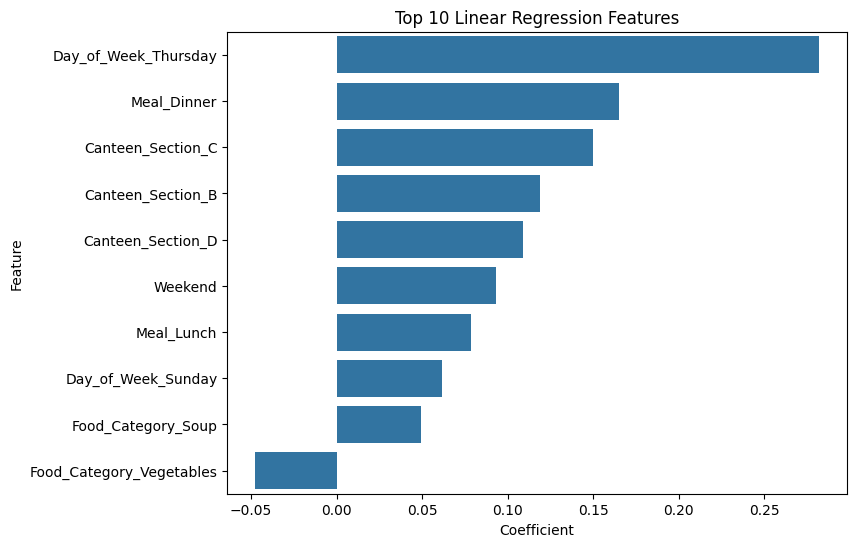

In [11]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=lr_importance.head(10),
    x="Coefficient",
    y="Feature"
)
plt.title(
    "Top 10 Linear Regression Features"
)
plt.show()

####Tuning & Training Decision Tree Regressor

In [12]:
from sklearn.model_selection import GridSearchCV
tree_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=tree_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

tree_grid.fit(X_train, y_train)

print("Best Parameters:", tree_grid.best_params_)

tree_model = tree_grid.best_estimator_

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


####Evaluating Decision Tree

In [13]:
tree_results = evaluate_model(
    tree_model,
    "Decision Tree"
)

Decision Tree
----------------
MAE: 1.2638
RMSE: 1.4615
R2: -0.0088



# Conclusion
#####The features provided (Day of Week, Meal Type, Food Category) show near-zero correlation with waste weight. The Decision Tree and Linear Regression models yield $R^2 \approx 0.00$, indicating that waste generation in this dataset occurs randomly relative to the menu. However, the models achieve a consistent Mean Absolute Error (MAE $\approx 1.26\text{ kg}$), serving as a baseline predictor equivalent to predicting the historical mean.

## Random Forest tuning


In [14]:
rf_params = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15],
    "min_samples_split":[2,5,10]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    rf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
rf_grid.fit(
    X_train,
    y_train
)
rf_model = rf_grid.best_estimator_

rf_grid.best_params_

{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}

####Evaluating Random Forest


In [15]:
rf_results = evaluate_model(
    rf_model,
    "Random Forest"
)

Random Forest
----------------
MAE: 1.2645
RMSE: 1.4603
R2: -0.0072



##TuningGradient Boosting

In [16]:
gb_params = {
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[2,3,5]

}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(
        random_state=42
    ),
    gb_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
gb_grid.fit(
    X_train,
    y_train
)
gb_model = gb_grid.best_estimator_

gb_grid.best_params_

{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}

##Evaluating Gradient Boosting

In [17]:
gb_results = evaluate_model(
    gb_model,
    "Gradient Boosting"
)

Gradient Boosting
----------------
MAE: 1.2613
RMSE: 1.4573
R2: -0.0031



##Tuning AdaBoost Regressor

In [18]:
ada_model = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostRegressor(learning_rate=0.1, n_estimators=100, random_state=42)

##Evaluating AdaBoost

In [19]:
ada_results = evaluate_model(
    ada_model,
    "AdaBoost"
)

AdaBoost
----------------
MAE: 1.2601
RMSE: 1.4558
R2: -0.0011



##Feature Importance Analysis

In [20]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
1,Month,0.104631
0,Unit_Price_per_kg,0.092486
4,Meal_Lunch,0.084245
3,Meal_Dinner,0.081401
10,Canteen_Section_D,0.077742
9,Canteen_Section_C,0.074136
8,Canteen_Section_B,0.074000
14,Day_of_Week_Thursday,0.072776
13,Day_of_Week_Sunday,0.037167
7,Food_Category_Vegetables,0.036433


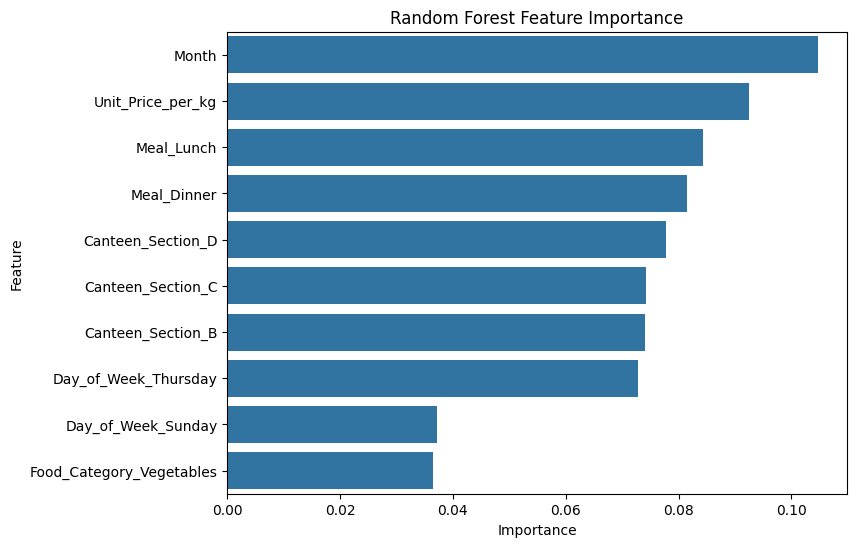

In [21]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title(
    "Random Forest Feature Importance"
)
plt.show()

In [22]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Cost_Loss",
        "Day",
        "Day_Number"
    ]
)

y=df["Waste_Weight_kg"]

##Model Comparison

In [23]:
comparison = pd.DataFrame({

"Model":[

"Linear Regression",
"Decision Tree",
"Random Forest",
"Gradient Boosting",
"AdaBoost"

],


"MAE":[

lr_results[0],
tree_results[0],
rf_results[0],
gb_results[0],
ada_results[0]

],


"RMSE":[

lr_results[1],
tree_results[1],
rf_results[1],
gb_results[1],
ada_results[1]

],


"R2":[

lr_results[2],
tree_results[2],
rf_results[2],
gb_results[2],
ada_results[2]

]

})


comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
4,AdaBoost,1.260119,1.455822,-0.001086
0,Linear Regression,1.260727,1.456986,-0.002688
3,Gradient Boosting,1.261319,1.457305,-0.003126
2,Random Forest,1.264514,1.460289,-0.007240
1,Decision Tree,1.263820,1.461451,-0.008843


In [24]:
def check_overfitting(model, name):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(name)
    print("----------------")
    print("Training R2:", round(train_r2,4))
    print("Testing R2 :", round(test_r2,4))
    print()


check_overfitting(lr_model, "Linear Regression")
check_overfitting(tree_model, "Decision Tree")
check_overfitting(rf_model, "Random Forest")
check_overfitting(gb_model, "Gradient Boosting")
check_overfitting(ada_model, "AdaBoost")

Linear Regression
----------------
Training R2: 0.0139
Testing R2 : -0.0027

Decision Tree
----------------
Training R2: 0.019
Testing R2 : -0.0088

Random Forest
----------------
Training R2: 0.0671
Testing R2 : -0.0072

Gradient Boosting
----------------
Training R2: 0.0091
Testing R2 : -0.0031

AdaBoost
----------------
Training R2: 0.0178
Testing R2 : -0.0011

